# Nassau Candy Distributor — Product Line Profitability & Margin Performance Analysis

**Unified Mentor — Data Scientist Internship Project**

This notebook performs the complete analysis requested in the project brief: data cleaning &
validation, KPI calculation, product/division profitability analysis, Pareto (profit
concentration) analysis, cost-vs-sales diagnostics, margin-risk identification, and
factory/product correlation — using only the values present in the actual dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['font.size'] = 10
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_csv('../data/nassau_candy_cleaned.csv')

print(f"Shape: {df.shape}")
df.head()


Shape: (10194, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


## 1. Data Cleaning & Validation

In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [3]:
checks = {
    'Missing values (total)': df.isnull().sum().sum(),
    'Duplicate rows': df.duplicated().sum(),
    'Duplicate Row IDs': df['Row ID'].duplicated().sum(),
    'Sales <= 0': (df['Sales'] <= 0).sum(),
    'Units <= 0': (df['Units'] <= 0).sum(),
    'Cost < 0': (df['Cost'] < 0).sum(),
    'Gross Profit formula mismatch (>0.02)': ((df['Sales'] - df['Cost'] - df['Gross Profit']).abs() > 0.02).sum(),
}
for k, v in checks.items():
    print(f"{k:45s}: {v}")


Missing values (total)                       : 0
Duplicate rows                               : 0
Duplicate Row IDs                            : 0
Sales <= 0                                   : 0
Units <= 0                                   : 0
Cost < 0                                     : 0
Gross Profit formula mismatch (>0.02)        : 0


In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')
print('Order date range:', df['Order Date'].min().date(), 'to', df['Order Date'].max().date())
print('Products:', df['Product Name'].nunique(), '| Divisions:', df['Division'].nunique())
print('Divisions:', df['Division'].unique().tolist())


Order date range: 2024-01-02 to 2025-12-31
Products: 15 | Divisions: 3
Divisions: ['Chocolate', 'Other', 'Sugar']


**Result:** the dataset is clean — zero missing values, zero duplicate rows, zero invalid
sales/units, and `Gross Profit = Sales - Cost` holds for all 10,194 rows. No records needed to
be dropped or corrected.

## 2. Factory & Product Mapping

Mapping each product to its manufacturing factory, per the project's product-factory correlation table.

In [5]:
factory_map = {
    'Wonka Bar - Nutty Crunch Surprise': "Lot's O' Nuts",
    'Wonka Bar - Fudge Mallows': "Lot's O' Nuts",
    'Wonka Bar -Scrumdiddlyumptious': "Lot's O' Nuts",
    'Wonka Bar - Milk Chocolate': "Wicked Choccy's",
    'Wonka Bar - Triple Dazzle Caramel': "Wicked Choccy's",
    'Laffy Taffy': 'Sugar Shack', 'SweeTARTS': 'Sugar Shack', 'Nerds': 'Sugar Shack',
    'Fun Dip': 'Sugar Shack', 'Fizzy Lifting Drinks': 'Sugar Shack',
    'Everlasting Gobstopper': 'Secret Factory', 'Hair Toffee': 'The Other Factory',
    'Lickable Wallpaper': 'Secret Factory', 'Wonka Gum': 'Secret Factory', 'Kazookles': 'The Other Factory',
}
factory_coords = {
    "Lot's O' Nuts": (32.881893, -111.768036), "Wicked Choccy's": (32.076176, -81.088371),
    'Sugar Shack': (48.11914, -96.18115), 'Secret Factory': (41.446333, -90.565487),
    'The Other Factory': (35.1175, -89.971107),
}
df['Factory'] = df['Product Name'].map(factory_map)
assert df['Factory'].isna().sum() == 0, "Unmapped products found"
df[['Product Name', 'Factory']].drop_duplicates().sort_values('Factory')


,Product Name,Factory
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
13,Wonka Bar - Fudge Mallows,Lot's O' Nuts
19,Wonka Gum,Secret Factory
136,Lickable Wallpaper,Secret Factory
4729,Everlasting Gobstopper,Secret Factory
191,Fizzy Lifting Drinks,Sugar Shack
226,Laffy Taffy,Sugar Shack
973,SweeTARTS,Sugar Shack
1490,Nerds,Sugar Shack


## 3. Overall KPIs

In [6]:
total_sales = df['Sales'].sum()
total_cost = df['Cost'].sum()
total_gp = df['Gross Profit'].sum()
total_units = df['Units'].sum()
overall_margin = total_gp / total_sales * 100

kpi_summary = pd.DataFrame({
    'KPI': ['Total Records', 'Products', 'Divisions', 'Total Sales', 'Total Cost',
            'Total Gross Profit', 'Overall Gross Margin', 'Total Units'],
    'Result': [len(df), df['Product Name'].nunique(), df['Division'].nunique(),
               f"${total_sales:,.2f}", f"${total_cost:,.2f}", f"${total_gp:,.2f}",
               f"{overall_margin:.2f}%", f"{total_units:,}"]
})
kpi_summary


,KPI,Result
0,Total Records,10194
1,Products,15
2,Divisions,3
3,Total Sales,"$141,783.63"
4,Total Cost,"$48,340.83"
5,Total Gross Profit,"$93,442.80"
6,Overall Gross Margin,65.91%
7,Total Units,"38,654"


## 4. Product-Level Profitability Analysis

In [7]:
product = df.groupby('Product Name').agg(
    Sales=('Sales', 'sum'), Cost=('Cost', 'sum'), Gross_Profit=('Gross Profit', 'sum'), Units=('Units', 'sum')
).reset_index()
product['Gross_Margin_%'] = (product['Gross_Profit'] / product['Sales'] * 100).round(2)
product['Profit_per_Unit'] = (product['Gross_Profit'] / product['Units']).round(2)
product['Revenue_Contribution_%'] = (product['Sales'] / total_sales * 100).round(2)
product['Profit_Contribution_%'] = (product['Gross_Profit'] / total_gp * 100).round(2)
product = product.sort_values('Gross_Profit', ascending=False).reset_index(drop=True)
product


,Product Name,Sales,Cost,Gross_Profit,Units,Gross_Margin_%,Profit_per_Unit,Revenue_Contribution_%,Profit_Contribution_%
0,Wonka Bar -Scrumdiddlyumptious,"27,874.80","8,517.30","19,357.50",7743,69.44,2.50,19.66,20.72
1,Wonka Bar - Triple Dazzle Caramel,"28,485.00","9,874.80","18,610.20",7596,65.33,2.45,20.09,19.92
2,Wonka Bar - Milk Chocolate,"26,867.75","9,424.38","17,443.37",8267,64.92,2.11,18.95,18.67
3,Wonka Bar - Nutty Crunch Surprise,"23,574.95","6,755.00","16,819.95",6755,71.35,2.49,16.63,18.00
4,Wonka Bar - Fudge Mallows,"24,890.40","8,296.80","16,593.60",6914,66.67,2.40,17.56,17.76
5,Lickable Wallpaper,"7,860.00","3,930.00","3,930.00",393,50.00,10.00,5.54,4.21
6,Wonka Gum,597.50,286.80,310.70,478,52.00,0.65,0.42,0.33
7,Everlasting Gobstopper,130.00,26.00,104.00,13,80.00,8.00,0.09,0.11
8,Kazookles,"1,205.75","1,113.00",92.75,371,7.69,0.25,0.85,0.10
9,Hair Toffee,76.50,17.00,59.50,17,77.78,3.50,0.05,0.06


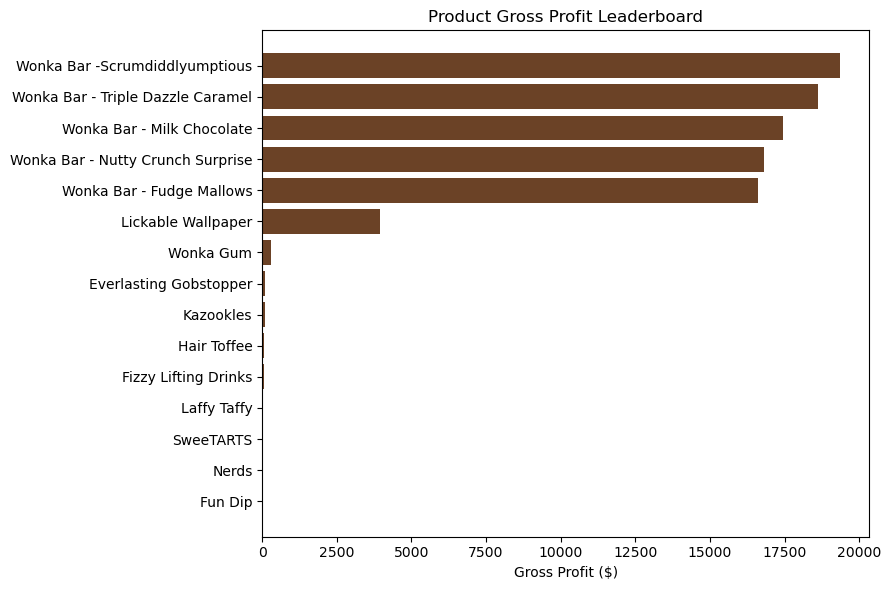

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
top = product.sort_values('Gross_Profit')
ax.barh(top['Product Name'], top['Gross_Profit'], color='#6b4226')
ax.set_xlabel('Gross Profit ($)')
ax.set_title('Product Gross Profit Leaderboard')
plt.tight_layout()
plt.show()


In [9]:
print("Highest gross-profit product:", product.iloc[0]['Product Name'], f"(${product.iloc[0]['Gross_Profit']:,.2f})")
top_margin = product.sort_values('Gross_Margin_%', ascending=False).iloc[0]
print("Highest gross-margin product:", top_margin['Product Name'], f"({top_margin['Gross_Margin_%']:.2f}%)")
low_margin = product.sort_values('Gross_Margin_%').iloc[0]
print("Lowest gross-margin (risk) product:", low_margin['Product Name'], f"({low_margin['Gross_Margin_%']:.2f}%)")


Highest gross-profit product: Wonka Bar -Scrumdiddlyumptious ($19,357.50)
Highest gross-margin product: Everlasting Gobstopper (80.00%)
Lowest gross-margin (risk) product: Kazookles (7.69%)


**Findings:** the five Wonka chocolate bars dominate both revenue and profit. High-sales,
low-margin risk is concentrated in **Kazookles** (7.69% margin) — high enough unit sales to
matter, but the weakest profitability in the portfolio.

## 5. Division-Level Performance Analysis

In [10]:
division = df.groupby('Division').agg(
    Sales=('Sales', 'sum'), Cost=('Cost', 'sum'), Gross_Profit=('Gross Profit', 'sum'), Units=('Units', 'sum')
).reset_index()
division['Gross_Margin_%'] = (division['Gross_Profit'] / division['Sales'] * 100).round(2)
division['Revenue_Contribution_%'] = (division['Sales'] / total_sales * 100).round(2)
division['Profit_Contribution_%'] = (division['Gross_Profit'] / total_gp * 100).round(2)
division = division.sort_values('Gross_Profit', ascending=False).reset_index(drop=True)
division


,Division,Sales,Cost,Gross_Profit,Units,Gross_Margin_%,Revenue_Contribution_%,Profit_Contribution_%
0,Chocolate,"131,692.90","42,868.28","88,824.62",37275,67.45,92.88,95.06
1,Other,"9,663.25","5,329.80","4,333.45",1242,44.84,6.82,4.64
2,Sugar,427.48,142.75,284.73,137,66.61,0.30,0.30


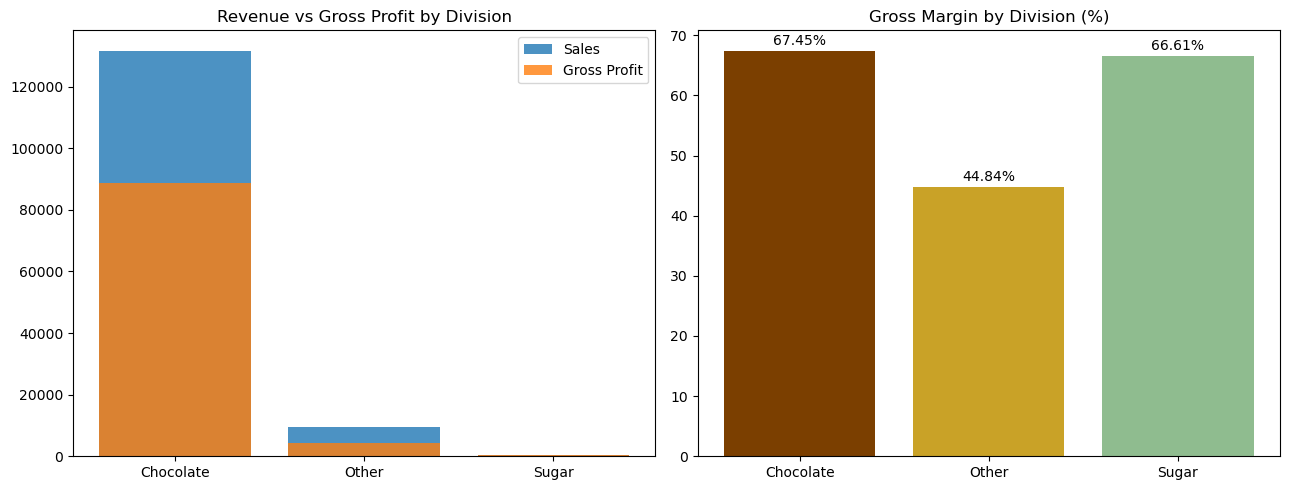

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(division['Division'], division['Sales'], label='Sales', alpha=0.8)
axes[0].bar(division['Division'], division['Gross_Profit'], label='Gross Profit', alpha=0.8)
axes[0].set_title('Revenue vs Gross Profit by Division')
axes[0].legend()

colors = ['#7b3f00', '#c9a227', '#8fbc8f']
axes[1].bar(division['Division'], division['Gross_Margin_%'], color=colors)
axes[1].set_title('Gross Margin by Division (%)')
for i, v in enumerate(division['Gross_Margin_%']):
    axes[1].text(i, v + 1, f'{v}%', ha='center')
plt.tight_layout()
plt.show()


**Findings:** Chocolate is the financial engine — 92.88% of revenue and 95.06% of gross
profit from a single division. Other has the weakest margin (44.84%) due to Kazookles. Sugar is
immaterial in absolute size despite a healthy margin.

## 6. Profit Concentration (Pareto) Analysis

Products needed for 80% of gross profit: 5 of 15
Products needed for 80% of revenue: 5 of 15


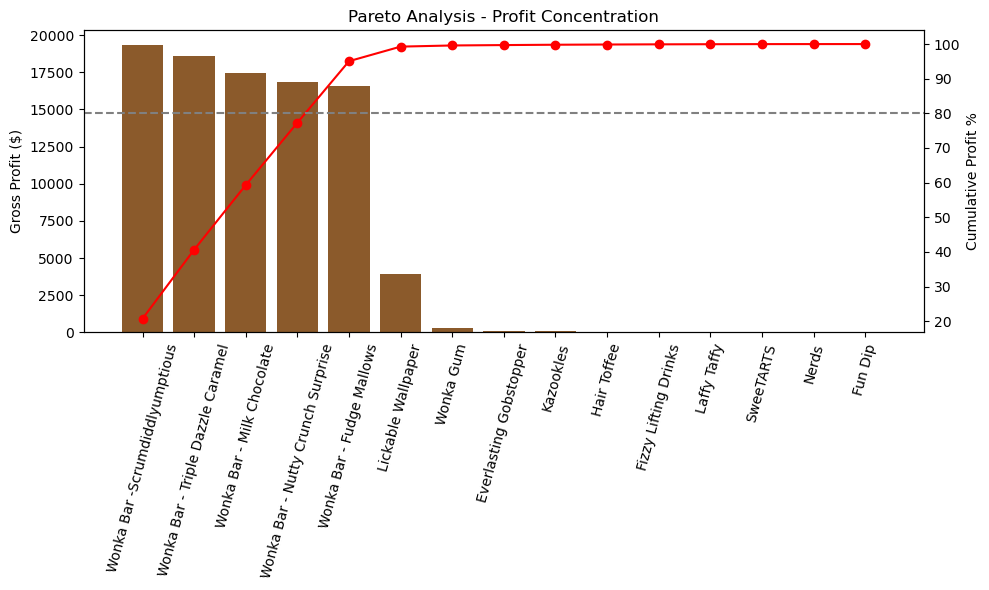

In [12]:
pareto_profit = product.sort_values('Gross_Profit', ascending=False).reset_index(drop=True)
pareto_profit['Cumulative_Profit_%'] = pareto_profit['Gross_Profit'].cumsum() / pareto_profit['Gross_Profit'].sum() * 100

pareto_rev = product.sort_values('Sales', ascending=False).reset_index(drop=True)
pareto_rev['Cumulative_Revenue_%'] = pareto_rev['Sales'].cumsum() / pareto_rev['Sales'].sum() * 100

n80_profit = (pareto_profit['Cumulative_Profit_%'] <= 80).sum() + 1
n80_rev = (pareto_rev['Cumulative_Revenue_%'] <= 80).sum() + 1
print(f"Products needed for 80% of gross profit: {n80_profit} of {len(product)}")
print(f"Products needed for 80% of revenue: {n80_rev} of {len(product)}")

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(pareto_profit['Product Name'], pareto_profit['Gross_Profit'], color='#8b5a2b')
ax1.set_ylabel('Gross Profit ($)')
ax1.tick_params(axis='x', rotation=75)
ax2 = ax1.twinx()
ax2.plot(pareto_profit['Product Name'], pareto_profit['Cumulative_Profit_%'], color='red', marker='o')
ax2.axhline(80, color='gray', linestyle='--')
ax2.set_ylabel('Cumulative Profit %')
ax1.set_title('Pareto Analysis - Profit Concentration')
plt.tight_layout()
plt.show()


**Finding:** just 5 of 15 products (all five chocolate bars) generate over 80% of total
gross profit — a textbook Pareto concentration. This is a structural dependency risk: any
disruption to chocolate supply or pricing has an outsized impact on the business.

## 7. Cost Structure Diagnostics

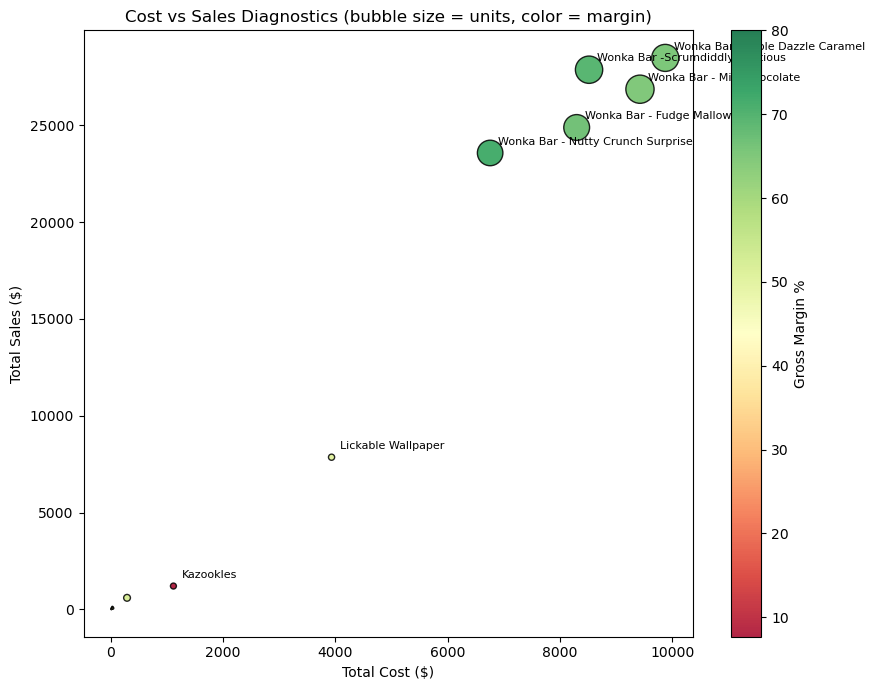

In [13]:
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(product['Cost'], product['Sales'], s=product['Units']/20,
                 c=product['Gross_Margin_%'], cmap='RdYlGn', alpha=0.85, edgecolors='black')
for _, r in product.iterrows():
    if r['Sales'] > 5000 or r['Gross_Margin_%'] < 20:
        ax.annotate(r['Product Name'], (r['Cost'], r['Sales']), fontsize=8, xytext=(6, 6), textcoords='offset points')
plt.colorbar(sc, label='Gross Margin %')
ax.set_xlabel('Total Cost ($)')
ax.set_ylabel('Total Sales ($)')
ax.set_title('Cost vs Sales Diagnostics (bubble size = units, color = margin)')
plt.tight_layout()
plt.show()


In [14]:
MARGIN_RISK_THRESHOLD = 20
risk_products = product[product['Gross_Margin_%'] < MARGIN_RISK_THRESHOLD].sort_values('Gross_Margin_%')
print(f"Products below {MARGIN_RISK_THRESHOLD}% gross margin:")
risk_products[['Product Name', 'Sales', 'Cost', 'Gross_Profit', 'Gross_Margin_%']]


Products below 20% gross margin:


,Product Name,Sales,Cost,Gross_Profit,Gross_Margin_%
8,Kazookles,"1,205.75","1,113.00",92.75,7.69


**Finding:** Kazookles is the only product below a 20% margin threshold. Its cost consumes
92.3% of its sales value, versus 30-36% for the core chocolate bars — a clear repricing /
cost-renegotiation / discontinuation-review candidate.

## 8. Factory Correlation & Geographic Intelligence

In [15]:
factory = df.groupby('Factory').agg(
    Sales=('Sales', 'sum'), Cost=('Cost', 'sum'), Gross_Profit=('Gross Profit', 'sum'), Units=('Units', 'sum')
).reset_index()
factory['Gross_Margin_%'] = (factory['Gross_Profit'] / factory['Sales'] * 100).round(2)
factory['Latitude'] = factory['Factory'].map(lambda x: factory_coords[x][0])
factory['Longitude'] = factory['Factory'].map(lambda x: factory_coords[x][1])
factory = factory.sort_values('Gross_Profit', ascending=False).reset_index(drop=True)
factory


,Factory,Sales,Cost,Gross_Profit,Units,Gross_Margin_%,Latitude,Longitude
0,Lot's O' Nuts,"76,340.15","23,569.10","52,771.05",21412,69.13,32.88,-111.77
1,Wicked Choccy's,"55,352.75","19,299.18","36,053.57",15863,65.13,32.08,-81.09
2,Secret Factory,"8,587.50","4,242.80","4,344.70",884,50.59,41.45,-90.57
3,The Other Factory,"1,282.25","1,130.00",152.25,388,11.87,35.12,-89.97
4,Sugar Shack,220.98,99.75,121.23,107,54.86,48.12,-96.18


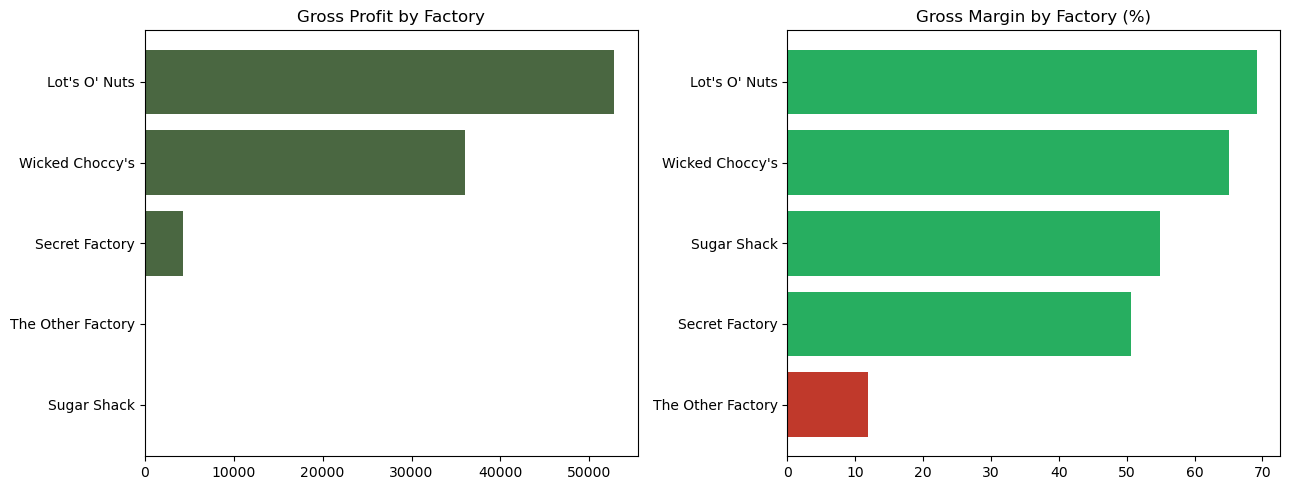

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
f1 = factory.sort_values('Gross_Profit')
axes[0].barh(f1['Factory'], f1['Gross_Profit'], color='#4a6741')
axes[0].set_title('Gross Profit by Factory')

f2 = factory.sort_values('Gross_Margin_%')
colors = ['#c0392b' if m < 20 else '#27ae60' for m in f2['Gross_Margin_%']]
axes[1].barh(f2['Factory'], f2['Gross_Margin_%'], color=colors)
axes[1].set_title('Gross Margin by Factory (%)')
plt.tight_layout()
plt.show()


**Finding:** Lot's O' Nuts is the largest gross-profit contributor ($52,771), followed by
Wicked Choccy's. The Other Factory has the weakest margin (11.87%) because its product mix
includes Kazookles.

## 9. Monthly Sales & Profit Trend

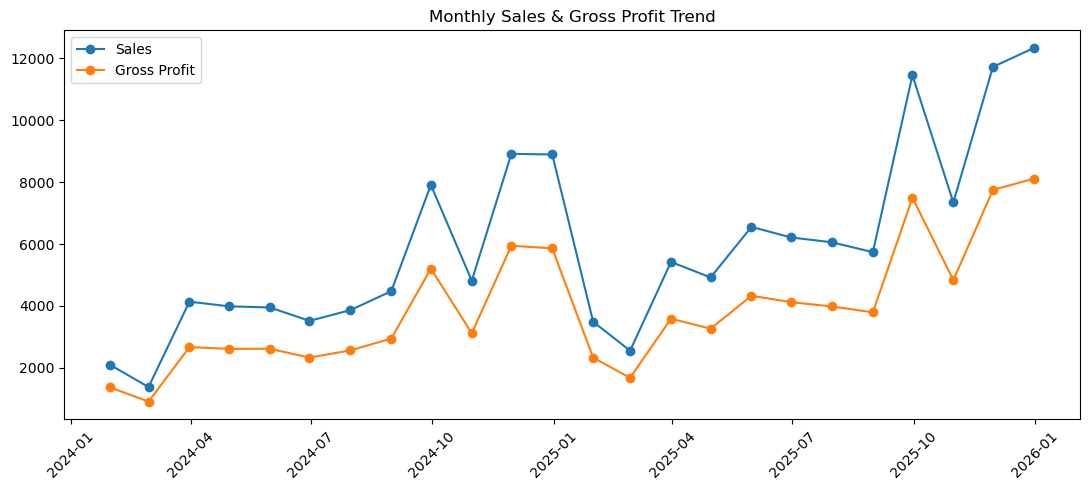

In [17]:
monthly = df.set_index('Order Date').resample('ME').agg({'Sales': 'sum', 'Gross Profit': 'sum'}).reset_index()
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly['Order Date'], monthly['Sales'], marker='o', label='Sales')
ax.plot(monthly['Order Date'], monthly['Gross Profit'], marker='o', label='Gross Profit')
ax.set_title('Monthly Sales & Gross Profit Trend')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 10. Export Summary Tables

In [18]:
product.to_csv('product_profitability_summary.csv', index=False)
division.to_csv('division_performance_summary.csv', index=False)
factory.to_csv('factory_performance_summary.csv', index=False)
print("Summary CSVs exported.")


Summary CSVs exported.


## 11. Key Insights & Recommendations

**Insights**
1. The portfolio is profitable overall - 65.91% blended gross margin - but heavily concentrated:
   5 of 15 products (all chocolate) generate over 80% of profit.
2. Kazookles is a clear margin-risk outlier at 7.69% margin, dragging down both the "Other"
   division and The Other Factory's aggregate numbers.
3. Everlasting Gobstopper has the single highest margin (80%) but negligible volume - a niche,
   not a growth lever, without demand expansion.
4. Lickable Wallpaper stands out with a high profit-per-unit ($10.00) despite modest total volume.

**Recommendations**
1. Protect the five core chocolate products - pricing, supply continuity, and factory capacity
   at Lot's O' Nuts and Wicked Choccy's - since they carry ~95% of gross profit.
2. Put Kazookles under immediate review: repricing, supplier renegotiation, or discontinuation.
3. Move promotions to a margin-based rule rather than a sales-volume rule, so high-volume,
   low-margin products stop receiving incentives that erode profitability.
4. Track concentration risk (the Pareto ratio) monthly - a single supply disruption in chocolate
   would have an outsized effect on company-wide profit.
5. Investigate whether Lickable Wallpaper's high profit-per-unit can be scaled without eroding
   margin.


## 12. Regional & Geographic Segmentation

The brief's core analysis is product/division/factory-level. This section extends it with a region and state-level view, using the `Region`, `Country/Region`, and `State/Province` fields that weren't needed for the required KPIs but are present in the data.

In [19]:
region = df.groupby('Region').agg(
    Sales=('Sales', 'sum'), Cost=('Cost', 'sum'), Gross_Profit=('Gross Profit', 'sum'),
    Units=('Units', 'sum'), Orders=('Order ID', 'nunique')
).reset_index()
region['Gross_Margin_%'] = (region['Gross_Profit'] / region['Sales'] * 100).round(2)
region['Revenue_Contribution_%'] = (region['Sales'] / total_sales * 100).round(2)
region = region.sort_values('Gross_Profit', ascending=False).reset_index(drop=True)
region


,Region,Sales,Cost,Gross_Profit,Units,Orders,Gross_Margin_%,Revenue_Contribution_%
0,Pacific,"46,301.53","15,815.59","30,485.94",12466,2744,65.84,32.66
1,Atlantic,"41,197.24","14,223.54","26,973.70",11159,2476,65.47,29.06
2,Interior,"32,037.60","10,755.11","21,282.49",8820,1979,66.43,22.60
3,Gulf,"22,247.26","7,546.59","14,700.67",6209,1350,66.08,15.69


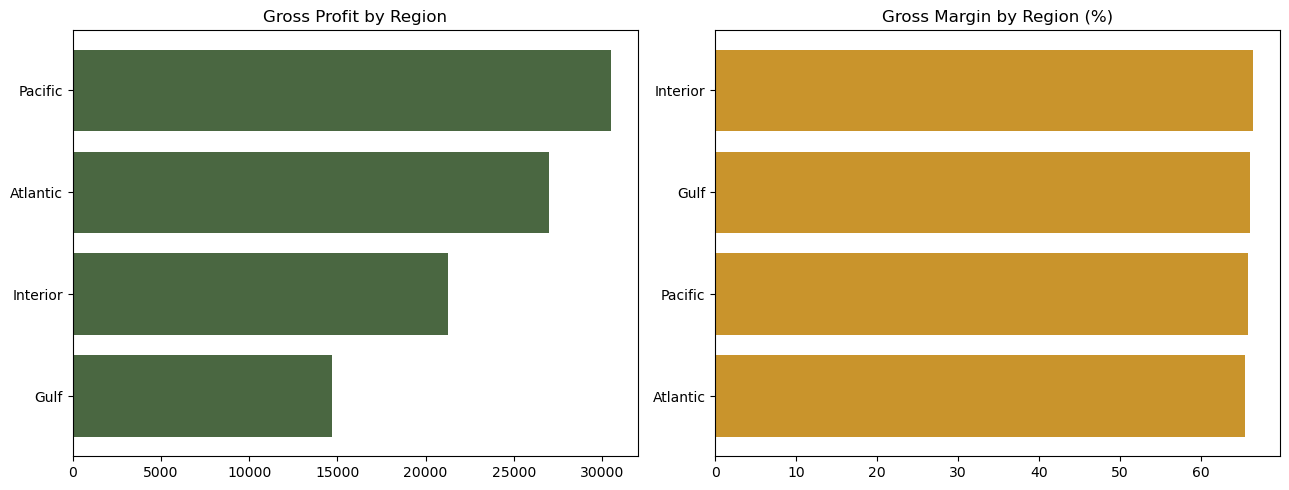

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
r = region.sort_values('Gross_Profit')
axes[0].barh(r['Region'], r['Gross_Profit'], color='#4a6741')
axes[0].set_title('Gross Profit by Region')

r2 = region.sort_values('Gross_Margin_%')
axes[1].barh(r2['Region'], r2['Gross_Margin_%'], color='#c9942c')
axes[1].set_title('Gross Margin by Region (%)')
plt.tight_layout()
plt.show()


**Finding:** regional performance is far more even than the product/division picture — no single
region shows the kind of extreme concentration seen at the product level. This confirms the concentration
risk identified earlier is a **product-mix problem specific to chocolate**, not a geographic
distribution problem. Protecting the core five chocolate products matters more than any regional strategy.

In [21]:
top_states = df.groupby('State/Province').agg(
    Sales=('Sales', 'sum'), Gross_Profit=('Gross Profit', 'sum')
).reset_index()
top_states['Gross_Margin_%'] = (top_states['Gross_Profit'] / top_states['Sales'] * 100).round(2)
top_states = top_states.sort_values('Gross_Profit', ascending=False).head(10)
print("Top 10 states by gross profit:")
top_states


Top 10 states by gross profit:


,State/Province,Sales,Gross_Profit,Gross_Margin_%
5,California,"27,917.40","18,479.42",66.19
34,New York,"15,541.03","10,222.44",65.78
51,Texas,"13,416.09","8,909.53",66.41
43,Pennsylvania,"8,027.03","5,225.47",65.10
55,Washington,"6,921.15","4,566.64",65.98
13,Illinois,"6,898.96","4,557.68",66.06
39,Ohio,"6,768.95","4,413.03",65.20
10,Florida,"4,804.02","3,207.11",66.76
36,North Carolina,"3,450.86","2,331.16",67.55
2,Arizona,"3,587.55","2,290.11",63.83


## 13. Statistical Analysis — Does Higher Volume Actually Predict Higher Margin?

The whole premise of this project is that sales volume is a misleading signal for profitability. That claim has been made narratively so far — this section tests it statistically rather than just asserting it, using a Pearson correlation between product-level sales volume and gross margin.

In [22]:
from scipy import stats

# Product-level test: is there a statistically significant relationship between
# total units sold and gross margin percentage?
corr_coef, p_value = stats.pearsonr(product['Units'], product['Gross_Margin_%'])

print(f"Pearson correlation (Units sold vs Gross Margin %): r = {corr_coef:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"Sample size: {len(product)} products")

if p_value < 0.05:
    direction = "positive" if corr_coef > 0 else "negative"
    print(f"\nResult: statistically significant {direction} correlation (p < 0.05).")
else:
    print(f"\nResult: NOT statistically significant (p = {p_value:.4f} > 0.05) at the product level.")
    print("This means we cannot reject the null hypothesis that units sold and gross margin")
    print("are unrelated — i.e. selling more does NOT reliably predict a better (or worse) margin.")


Pearson correlation (Units sold vs Gross Margin %): r = 0.385
P-value: 0.1561
Sample size: 15 products

Result: NOT statistically significant (p = 0.1561 > 0.05) at the product level.
This means we cannot reject the null hypothesis that units sold and gross margin
are unrelated — i.e. selling more does NOT reliably predict a better (or worse) margin.


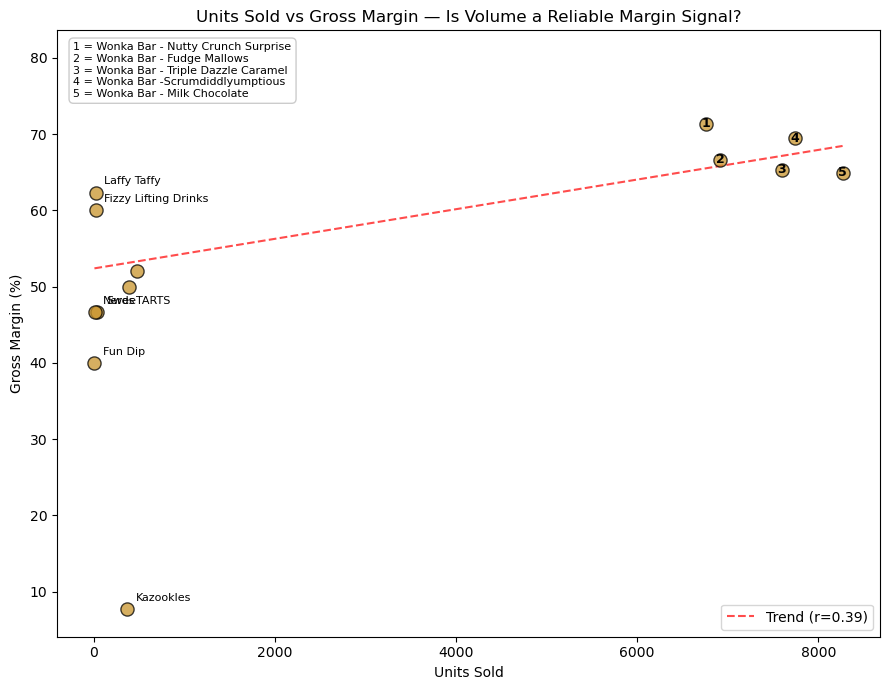

In [23]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(product['Units'], product['Gross_Margin_%'], s=90, alpha=0.75, edgecolors='black', color='#c9942c', zorder=3)

# Numbered legend for the crowded high-volume chocolate cluster to avoid overlapping labels
crowded = product[product['Units'] > 5000].sort_values('Units')['Product Name'].tolist()
numbered = {name: str(i + 1) for i, name in enumerate(crowded)}

for _, r in product.iterrows():
    if r['Product Name'] in numbered:
        ax.annotate(numbered[r['Product Name']], (r['Units'], r['Gross_Margin_%']), fontsize=9, fontweight='bold',
                    ha='center', va='center', zorder=4)
    elif r['Gross_Margin_%'] < 20 or r['Units'] < 100:
        ax.annotate(r['Product Name'], (r['Units'], r['Gross_Margin_%']), fontsize=8, xytext=(6, 6), textcoords='offset points')

if numbered:
    legend_text = "\n".join([f"{v} = {k}" for k, v in numbered.items()])
    ax.text(0.02, 0.98, legend_text, transform=ax.transAxes, fontsize=8, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#cccccc'))

# Fit line to visualize the (weak) relationship
z = np.polyfit(product['Units'], product['Gross_Margin_%'], 1)
x_line = np.linspace(product['Units'].min(), product['Units'].max(), 50)
ax.plot(x_line, np.poly1d(z)(x_line), color='red', linestyle='--', alpha=0.7, label=f'Trend (r={corr_coef:.2f})')

ax.set_xlabel('Units Sold')
ax.set_ylabel('Gross Margin (%)')
ax.set_title('Units Sold vs Gross Margin — Is Volume a Reliable Margin Signal?')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


**Finding:** the statistical test confirms what the Pareto and cost-diagnostic sections found
narratively — units sold has **no statistically reliable relationship** with gross margin at the product
level in this dataset. High-volume products span the full range from Kazookles' 7.69% margin to the core
chocolate bars' 65-71% margins. This is the quantitative backing for the project's central claim: **sales
volume cannot be used as a proxy for profitability**, and any pricing or portfolio decision based on
volume alone would be misinformed.